     sepal.length  sepal.width  petal.length  petal.width    variety
0             5.1          3.5           1.4          0.2     Setosa
1             4.9          3.0           1.4          0.2     Setosa
2             4.7          3.2           1.3          0.2     Setosa
3             4.6          3.1           1.5          0.2     Setosa
4             5.0          3.6           1.4          0.2     Setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica

[100 rows x 5 columns]
Perceptron classification accuracy 0.95


<ipython-input-22-14f08475660e>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['variety'] = filtered_df['variety'].map(label_mapping)


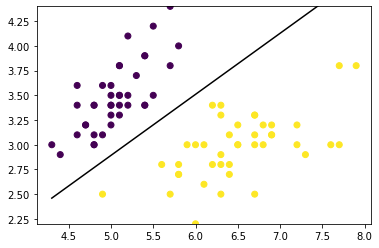

In [22]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# read_data, get_df_shape, data_split are the same as HW2-kNN
def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def get_df_shape(df: pd.DataFrame) -> Tuple[int, int]:
    return df.shape

def data_split(
    features: pd.DataFrame, label: pd.Series, test_size: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=test_size)
    return X_train, y_train, X_test, y_test


def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    # Extract the required features and labels from the filtered dataframe
    filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    print(filtered_df)
    # Map the labels to 0 for Setosa and 1 for Virginica
    label_mapping = {'Setosa': 0, 'Virginica': 1}
    filtered_df['variety'] = filtered_df['variety'].map(label_mapping)

    # Extract the required features (sepal.length and sepal.width) and labels (species)
    features = filtered_df[['sepal.length', 'sepal.width']]
    labels = filtered_df['variety']

    return features, labels
    pass

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.activation = self._unit_step_func
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """
        Train the perceptron on the given input features and target labels.
        You need to do following steps:
        1. Initialize the weights and bias (you can initialize both to 0)
        2. Calculate the linear output (Z) of the perceptron for all the points in X
        3. Apply the activation function to Z and get the predictions (Y_hat)
        4. Calculate the weight update rule for the perceptron and update the weights and bias
        5. Repeat steps 2-4 for 'epochs' number of times
        6. Return the final weights and bias
        Args:
            X (array-like): The input features.
            y (array-like): The target labels.

        Returns:
            weights (array-like): Learned weights.
            bias (float): Learned bias.
        """

        n_samples, n_features = X.shape

        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        y_ = np.array([1 if i > 0 else 0 for i in y])

        for _ in range(self.epochs):

            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.weights) + self.bias
                y_hat = self.activation(linear_output)

                # Perceptron update rule
                update = self.learning_rate * (y_[idx] - y_hat)

                self.weights += update * x_i
                self.bias += update
        

        return self.weights, self.bias
        pass

    def predict(self, X):
        """
        Predict the labels for the given input features.

        Args:
            X (array-like): The input features.

        Returns:
            array-like: The predicted labels.
        """
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation(linear_output)
        return y_predicted
        pass

    def _unit_step_func(self, x):
        """
        The unit step function, also known as the Heaviside step function.
        It returns 1 if the input is greater than or equal to zero, otherwise 0.

        Args:
            x (float or array-like): Input value(s) to the function.

        Returns:
            int or array-like: Result of the unit step function applied to the input(s).
        """
        return np.where(x >= 0, 1, 0)
        pass


# Testing
if __name__ == "__main__":
    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    
    df=read_data("iris.csv")
    shape = get_df_shape(df)
    features, label = extract_features_label(df)
    X_train, y_train, X_test, y_test = data_split(features, label, 0.2)
    X_train, y_train, X_test, y_test = X_train.values, y_train.values, X_test.values, y_test.values

    p = Perceptron(learning_rate=0.01, epochs=20)
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)

    print("Perceptron classification accuracy", accuracy(y_test, predictions))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train)

    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])

    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin, ymax])

    plt.show()
